# What Are Echoes?

In this note, we explore how math can used to produce *echoes* (echoes echoes echoes ...)!

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

from io import BytesIO
from IPython.display import Audio, display, clear_output
from ipywidgets import interact
from scipy.io import wavfile
from scipy.signal import fftconvolve

# What is Sound?

In order to understand what an echo is mathematically, we first have to understand how to represent sound. But what exactly is *sound*? When something produces a noise, it exerts a force on the nearby air molecules (or whatever other surrounding medium). Heuristically, this pushes some molecules closer together in some areas while creating gaps in others. More accurately, it changes the momentum of the nearby particles, producing a change in the local *pressure*. This exerts a net force on neighboring air molecules, and the process propagates. So really we can view *sound as the propagation of a change in local pressure through the air*. This local pressure is often referred to as the *amplitude* of the sound wave.

We can visualize this as a *wave*, which plots the local pressure as a function of position, and watch how it propagates over time. Here is a simple example.

In [35]:
x = np.linspace(-10, 10, 1000)

@interact(t=(0, 20, 0.1))
def plot(t=0):
    plt.figure(figsize=(5, 2))
    plt.plot(x, np.sinc(x + 10 - t))
    plt.xlim(-10, 10)
    plt.ylim(-0.5, 1.5)
    plt.title("Sound Wave Propagation")
    plt.ylabel('Local Pressure')
    plt.xlabel('Position')

interactive(children=(FloatSlider(value=0.0, description='t', max=20.0), Output()), _dom_classes=('widget-inte…

Of course, we only hear the noise at a single location: wherever we happen to be standing (or whereever the microphone is located). In this sense, it sometimes makes a bit more sense to look at how the local pressure *at a specific point* evolves over time. If you have ever used an oscilloscope or seen an audio waveform, this is exactly what is plotted. For example, below we create a short plucked note and study its waveform. Note how the amplitude dies off as time goes on, and correspondingly the noise gets quieter.

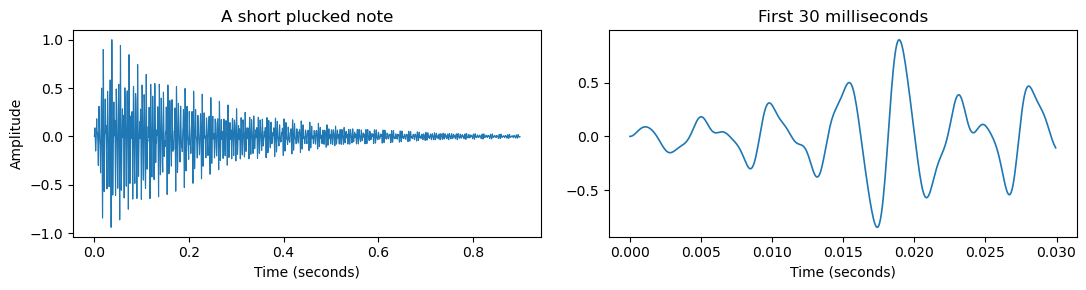

In [36]:
# Create an awesome audio wave
SAMPLE_RATE = 16_000
duration = 0.9
audio_time = np.arange(int(SAMPLE_RATE * duration)) / SAMPLE_RATE

# A short A-major-like pluck: a fundamental together with several overtones.
frequencies = [220, 277.18, 329.63, 440, 660]
weights = [1.0, 0.55, 0.45, 0.25, 0.12]
envelope = (1 - np.exp(-80 * audio_time)) * np.exp(-4.5 * audio_time)
source_audio = envelope * sum(
    weight * np.sin(2 * np.pi * frequency * audio_time)
    for frequency, weight in zip(frequencies, weights)
)
source_audio /= np.max(np.abs(source_audio))

def plot_audio(signal, sample_rate, title):
    times = np.arange(len(signal)) / sample_rate
    detail_samples = min(len(signal), int(0.03 * sample_rate))
    fig, axes = plt.subplots(1, 2, figsize=(11, 3))
    axes[0].plot(times, signal, linewidth=0.8)
    axes[0].set(title=title, xlabel="Time (seconds)", ylabel="Amplitude")
    axes[1].plot(times[:detail_samples], signal[:detail_samples], linewidth=1.2)
    axes[1].set(title="First 30 milliseconds", xlabel="Time (seconds)")
    plt.tight_layout()
    plt.show()

def impulse_response(sample_rate, taps):
    """Create an impulse response from (delay in seconds, amplitude) pairs."""
    length = int(round(max(delay for delay, _ in taps) * sample_rate)) + 1
    response = np.zeros(length)
    for delay, amplitude in taps:
        response[int(round(delay * sample_rate))] += amplitude
    return response

plot_audio(source_audio, SAMPLE_RATE, "A short plucked note")
display(Audio(source_audio, rate=SAMPLE_RATE))

## What is an Echo?

Heuristically, an *echo* occurs when a sound repeats after a fixed delay. A perfect echo copies the original signal without changing its amplitude or shape. Below, the sound begins again every two seconds.

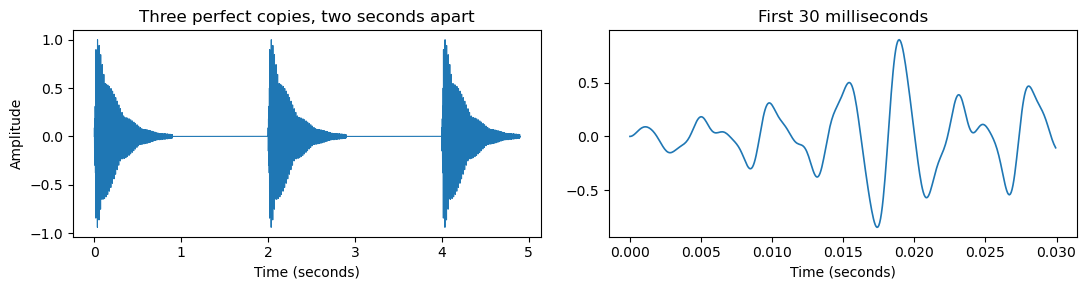

In [37]:
perfect_echo_response = impulse_response(
    SAMPLE_RATE, [(0.0, 1.0), (2.0, 1.0), (4.0, 1.0)]
)
perfect_echo = fftconvolve(source_audio, perfect_echo_response)

plot_audio(perfect_echo, SAMPLE_RATE, "Three perfect copies, two seconds apart")
display(Audio(perfect_echo, rate=SAMPLE_RATE))

## Convolving Signals and Impulse Responses

Suppose we had a given audio wave, and we wanted to repeat it every $2$ seconds. Heuristically, we just want to copy the wave at these intervals, exactly as we do in the previous cell. But how do we mathematically quantify this "copy" operation. Our key tool will be an operation called *convolution* which takes two signals $f(t), g(t)$ and produces a new signal by

$$h(t) := \int f(\tau) g(t - \tau) \; d\tau$$

In words, convolution fixes $t$, reflects and shifts one signal to form $g(t-\tau)$, multiplies it pointwise by $f(\tau)$, and adds the resulting overlap over all $\tau$. Moving the slider below lets us watch this process.

In [38]:
tau_grid = np.linspace(-6, 6, 1_501)
t_grid = np.linspace(-5, 5, 501)

def f(signal_time):
    return np.exp(-signal_time**2)

def g(signal_time):
    return 0.8 * np.exp(-((signal_time - 0.8) / 1.25) ** 2)

f_values = f(tau_grid)
convolution_values = np.array([
    np.trapz(f_values * g(t - tau_grid), tau_grid) for t in t_grid
])

@interact(t=(-5.0, 5.0, 0.1))
def show_convolution(t=0.0):
    shifted_g = g(t - tau_grid)
    product = f_values * shifted_g
    convolution_at_t = np.trapz(product, tau_grid)

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

    axes[0].plot(t_grid, convolution_values, color="#31543f", linewidth=2)
    axes[0].scatter([t], [convolution_at_t], color="#c76842", s=65, zorder=3)
    axes[0].axvline(t, color="#c76842", linestyle=":", alpha=0.7)
    axes[0].set(
        title=rf"Convolution: $(f*g)({t:.1f})={convolution_at_t:.3f}$",
        xlabel="t", ylabel="(f * g)(t)", xlim=(-5, 5), ylim=(0, 1.6),
    )

    axes[1].plot(tau_grid, f_values, label=r"$f(\tau)$", color="#31543f", linewidth=2)
    axes[1].plot(tau_grid, shifted_g, label=r"$g(t-\tau)$", color="#c76842", linewidth=2)
    axes[1].fill_between(tau_grid, product, color="#d9aa83", alpha=0.45, label="product")
    axes[1].set(
        title="The overlap being integrated", xlabel=r"$\tau$",
        ylabel="Amplitude", xlim=(-6, 6), ylim=(0, 1.1),
    )
    axes[1].legend(frameon=False)
    plt.tight_layout()
    plt.show()

The simplest impulse response is the *unit impulse* $\delta$, which is concentrated at time zero. It acts as the identity for convolution: $f*\delta=f$. A delayed impulse $\delta(t-D)$ produces a delayed copy $f(t-D)$.

More generally, convolving against a weighted collection of impulses creates multiple delayed copies of a signal, producing the desired echo.

#### A Mathematical Aside


We can encode the timing and strength of the echoes in an *impulse response* $h$. If $x[n]$ is the original digital signal and we want copies after $D,2D,\ldots$ samples, then a perfect three-copy echo uses

$$h[n] = \delta[n] + \delta[n-D] + \delta[n-2D].$$

The echoed signal is the convolution

$$y[n]=(x*h)[n]=\sum_k x[k]h[n-k].$$

Because $h$ is nonzero only at a few delays, this sum simply places shifted copies of $x$ at those locations. The Fourier transform turns convolution into multiplication:

$$\widehat{y}(\omega)=\widehat{x}(\omega)\widehat{h}(\omega).$$

This is the central computational idea: a room changes a sound by multiplying its frequencies by the room's frequency response, or equivalently by convolving the sound with the room's impulse response in time.

### Why does the unit impulse reproduce a signal?

For a discrete signal, the unit impulse $\delta[n]$ equals $1$ at $n=0$ and $0$ everywhere else. Therefore

$$
(f*\delta)[n]=\sum_k f[k]\delta[n-k]=f[n].
$$

Every term in the sum vanishes except the one with $k=n$. The plot below shows this identity numerically: the convolution lies exactly on top of the original signal.

In [ ]:
sample_indices = np.arange(-40, 41)
discrete_signal = (
    np.exp(-((sample_indices + 8) / 10) ** 2)
    - 0.55 * np.exp(-((sample_indices - 13) / 7) ** 2)
)
unit_impulse = np.zeros_like(discrete_signal)
unit_impulse[len(unit_impulse) // 2] = 1.0
reconstructed_signal = np.convolve(discrete_signal, unit_impulse, mode="same")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
axes[0].plot(sample_indices, discrete_signal, color="#31543f", linewidth=2)
axes[0].set(title=r"Original signal $f[n]$", xlabel=r"$n$", ylabel="Amplitude")

markerline, stemlines, baseline = axes[1].stem(sample_indices, unit_impulse)
plt.setp(markerline, color="#c76842", markersize=6)
plt.setp(stemlines, color="#c76842", linewidth=1.5)
plt.setp(baseline, color="#777777", linewidth=0.8)
axes[1].set(title=r"Unit impulse $\delta[n]$", xlabel=r"$n$", ylim=(-0.1, 1.15))

axes[2].plot(sample_indices, discrete_signal, color="#31543f", linewidth=4, alpha=0.35, label=r"$f[n]$")
axes[2].plot(sample_indices, reconstructed_signal, color="#c76842", linestyle="--", linewidth=2, label=r"$(f*\delta)[n]$")
axes[2].set(title="The two curves coincide", xlabel=r"$n$")
axes[2].legend(frameon=False)

for axis in axes:
    axis.grid(alpha=0.15)
plt.tight_layout()
plt.show()

print(f"Maximum reconstruction error: {np.max(np.abs(discrete_signal - reconstructed_signal)):.1e}")

## Damping

Real echoes are not perfect repetitions: each reflection loses energy, and overlapping reflections can interfere constructively or destructively. The exact pattern depends on the geometry and materials of the space. A simple model multiplies the $k$th copy by a damping factor $0<\alpha<1$:

$$h[n]=\sum_{k=0}^{K}\alpha^k\delta[n-kD].$$

Here is the same plucked note with five progressively quieter repetitions.

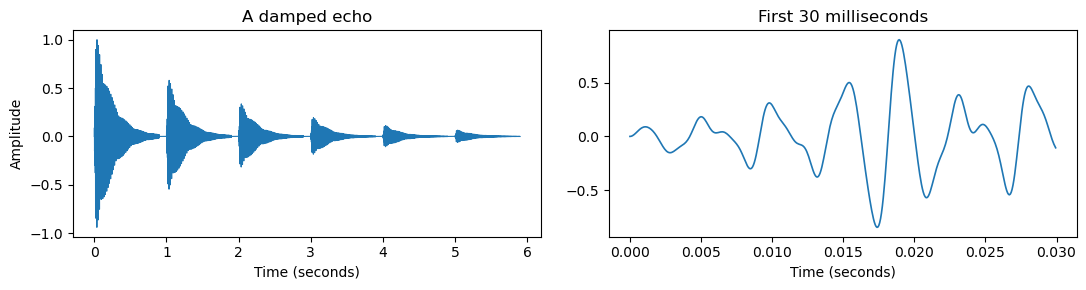

In [39]:
delay_seconds = 1.0
damping = 0.58
damped_response = impulse_response(
    SAMPLE_RATE,
    [(k * delay_seconds, damping**k) for k in range(6)],
)
damped_echo = fftconvolve(source_audio, damped_response)
damped_echo /= np.max(np.abs(damped_echo))

plot_audio(damped_echo, SAMPLE_RATE, "A damped echo")
display(Audio(damped_echo, rate=SAMPLE_RATE))

## Producing Echoes

Bringing this all together, let's produce an echo! Acousticians characterize a venue by recording its *impulse response*: roughly, the sound the room produces after a single sharp click. Convolving any dry recording with this response makes it sound as though it were played in that room.

The responses below are intentionally simple synthetic models rather than measurements of particular buildings. Their early reflections and exponentially decaying tails illustrate how room size and reverberation time affect sound. Upload a mono or stereo WAV file, select a venue, and press **Apply venue**. For speed, the demonstration processes at most the first 15 seconds.

> **Note:** File-upload widgets work when this notebook is run in Jupyter. A static rendering on GitHub or a website will display the explanation but cannot execute the uploader.

In [40]:
VENUES = {
    "Original (no echo)": None,
    "Treated studio": {"duration": 0.18, "decay": 30.0, "tail": 0.010,
                       "early": [(0.0, 1.0), (0.012, 0.18), (0.027, 0.10)]},
    "Small room": {"duration": 0.65, "decay": 9.0, "tail": 0.018,
                   "early": [(0.0, 1.0), (0.024, 0.42), (0.049, 0.28), (0.083, 0.16)]},
    "Concert hall": {"duration": 2.4, "decay": 2.8, "tail": 0.022,
                     "early": [(0.0, 1.0), (0.052, 0.55), (0.089, 0.38), (0.143, 0.25)]},
    "Cathedral": {"duration": 4.8, "decay": 1.35, "tail": 0.025,
                  "early": [(0.0, 1.0), (0.095, 0.62), (0.181, 0.45), (0.310, 0.30)]},
}

def make_venue_response(name, sample_rate):
    profile = VENUES[name]
    if profile is None:
        # Convolution with this unit impulse leaves the recording unchanged.
        return np.array([1.0])
    times = np.arange(int(profile["duration"] * sample_rate) + 1) / sample_rate
    rng = np.random.default_rng(2026)
    response = profile["tail"] * rng.normal(size=len(times)) * np.exp(-profile["decay"] * times)
    response += impulse_response(sample_rate, profile["early"] + [(profile["duration"], 0.0)])
    response /= np.max(np.abs(response))
    return response

def pcm_to_float(samples):
    if np.issubdtype(samples.dtype, np.floating):
        return samples.astype(float)
    if samples.dtype == np.uint8:
        return (samples.astype(float) - 128.0) / 128.0
    scale = max(abs(np.iinfo(samples.dtype).min), np.iinfo(samples.dtype).max)
    return samples.astype(float) / scale

def first_uploaded_file(upload_value):
    # ipywidgets 7 stores a dict; ipywidgets 8 stores a tuple of dicts.
    if isinstance(upload_value, dict):
        return next(iter(upload_value.values()))
    return upload_value[0]

upload = widgets.FileUpload(accept=".wav,audio/wav", multiple=False, description="Upload WAV")
venue = widgets.Dropdown(options=list(VENUES), value="Original (no echo)", description="Venue")
apply_button = widgets.Button(description="Apply venue", button_style="primary")
venue_output = widgets.Output()

def apply_selected_venue(_):
    with venue_output:
        clear_output(wait=True)
        if not upload.value:
            print("Upload a WAV file first.")
            return
        try:
            uploaded = first_uploaded_file(upload.value)
            sample_rate, samples = wavfile.read(BytesIO(bytes(uploaded["content"])))
            dry = pcm_to_float(samples)
            if dry.ndim == 2:
                dry = dry.mean(axis=1)
            dry = dry[: 15 * sample_rate]
            peak = np.max(np.abs(dry))
            if peak == 0:
                raise ValueError("The uploaded file is silent.")
            dry /= peak

            response = make_venue_response(venue.value, sample_rate)
            wet = fftconvolve(dry, response)
            wet /= max(1.0, np.max(np.abs(wet)))

            title = (
                "Your original recording"
                if venue.value == "Original (no echo)"
                else f"Your recording in a {venue.value.lower()}"
            )
            plot_audio(wet, sample_rate, title)
            display(Audio(wet, rate=sample_rate))
        except Exception as error:
            print(f"Could not process this WAV file: {error}")

apply_button.on_click(apply_selected_venue)
display(widgets.VBox([widgets.HBox([upload, venue, apply_button]), venue_output]))